In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#%cd /content/drive/MyDrive/FS_Attack-main

In [ ]:
%cd /content/drive/MyDrive/FS_Attack-main

/content/drive/MyDrive/FS_Attack-main


In [ ]:
pip install saliency

In [ ]:
import argparse
import torch
import torchvision
import torch.nn.functional as F
import numpy as np
import json

from nn.enums import ExplainingMethod
from nn.networks import ExplainableNet
from nn.utils import get_expl, plot_overview, clamp, load_image, make_dir
from nn.utils import gini_tensor, load_numpy, load_image_nopreprocess, show_expl
from nn.utils import gini_numpy, gini_tensor2, gini_tensor_ori, gini_tensor_double
from nn.utils import torch_to_image_ver2, png_to_jpeg, heatmap_to_image
from nn.utils import get_center_attack_matrix, show_expl_title, topk_intersection, show_expl_title_return_im
import samples.samples as DS
from models.mytool import * # 切換 model 的 function 跟 get_beta  #Switch model function and get_beta
import re #正規表達式 lib # regular expression
from nn.imagetool import * # 印各種圖片(灰階 熱點) #Print various pictures grayscale
import saliency.core as saliency
from PIL import Image
from matplotlib import pylab as P
import matplotlib.pyplot as plt
import matplotlib as mpl
from collections import defaultdict
from skimage.metrics import structural_similarity
from skimage.metrics import mean_squared_error
from skimage.metrics import peak_signal_noise_ratio
#from skimage.measure import compare_ssim
from skimage.metrics import structural_similarity as ssim

from scipy.stats import pearsonr
torch.set_printoptions(precision=7) # tensor 小數點後7位
%matplotlib inline
#要加這一行才有辦法直接用 imshow印出圖片 且只要加一次 所以加在最前面
# Only by adding this line can we directly use imshow to print the picture.
# And it only needs to be added once, so it is added at the front.

### 基本設定
### Basic Configuration

In [ ]:
#from mytool import set_parameter_requires_grad
#DATASET = 'imagenet'
DATASET = 'cifar10'
MODEL = 'VGG16' # ['RESNET50','_DENSENET121','VGG16','INCEPTIONV3','MOBILENETV2']
img_number = 100
size = 32 #224 #299 # 改變圖片大小 cifar10 原本是32x32
#""""""""""""""""""""""""""""""""""
# resnet 224
# alexnet 224
# vgg 224
# squeezenet 224
# mobilenet 224
# densenet 224
# inception 299
#""""""""""""""""""""""""""""""""""
#config_path = '/tf/XAI_Attack/config/model_config.json'
config_path = '/content/drive/MyDrive/FS_Attack-main/config/model_config.json'
#config_path = '/content/drive/MyDrive/Colab Notebooks/FS_Attack-main/config/model_config.json'
config = json.load(open(config_path))['{}_{}_{}'.format('torch', MODEL, DATASET)]
#label_dict = getattr(dataset_label, DATASET)
#model_types = re.findall("^([a-z]+)", config['model'])[0]
nb_classes = config['label']
# model_tsai = TORCH_MODEL(model_name = MODEL, dataset = DATASET, gpu = torch.cuda.is_available())
ds = getattr(DS, DATASET)
print('ds type: ',type(ds))
print('ds[0] type: ',type(ds[0]),ds[0])
indices = torch.randperm(len(ds.targets))[:img_number].numpy().astype(int) #隨機抽 img_number 張圖
images_list, labels = [np.array(ds[i][0].resize((size,size)).convert('RGB')) for i in indices], [np.array(ds[i][1]) for i in indices]
print('images_list type:',type(images_list))
images_arr, labels = np.array(images_list).astype('float32'), np.array(labels)
print('images_arr type:',type(images_arr),images_arr.shape)
labels_torch = torch.from_numpy(labels)

images = torch.tensor(images_arr)
print('images:',type(images),images.shape)
print('labels:',labels.shape)
print('model:',MODEL)
print('dataset:',DATASET)

ds type:  <class 'torchvision.datasets.cifar.CIFAR10'>
ds[0] type:  <class 'tuple'> (<PIL.Image.Image image mode=RGB size=32x32 at 0x7B79F408CA50>, 3)
images_list type: <class 'list'>
images_arr type: <class 'numpy.ndarray'> (100, 32, 32, 3)
images: <class 'torch.Tensor'> torch.Size([100, 32, 32, 3])
labels: (100,)
model: VGG16
dataset: cifar10


In [ ]:
print(images.shape)

torch.Size([100, 32, 32, 3])


### 讀取圖片 Read Pictures

In [ ]:
!pip install opencv-python

In [ ]:
import cv2
img = 'tmp_image/'+'1'+'.jpeg'
img = cv2.imread(img)
print(img.shape)

(224, 224, 3)


In [ ]:
from torchvision import transforms
from PIL import Image

# Define the preprocessing transformation
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

# Load and preprocess the image directly with PIL
img_path = 'tmp_image/1.jpeg'  # Adjust the path if needed
img = Image.open(img_path).convert('RGB')  # Ensure it's RGB mode

# Apply the preprocessing transformations
img_tensor = preprocess(img).unsqueeze(0)


In [ ]:
print(img_tensor.shape)

torch.Size([1, 3, 224, 224])


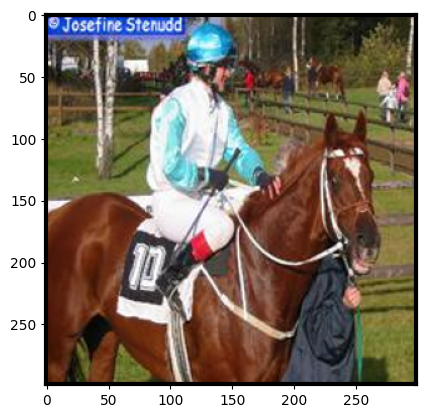

In [ ]:
num_iter = 150
#img = 'data/collie4.jpeg' #要攻擊的圖
#img = 'good_images/example_627_ver2/x.jpeg'
case = '1'
exp_method = 'lrp' #  choices=['lrp', 'guided_backprop', 'gradient', 'integrated_grad', 'pattern_attribution', 'grad_times_input']
#img = 'tmp_image/'+case+'.jpeg'
img = 'tmp_image/'+case+'.jpeg'
#img = 'temp_result/case_'+case+'.jpeg'

red = 'nn/RED.jpeg'
lr = 0.0002
cuda = True
output_dir = 'temp_result/'
beta_growth = True
prefactors = [1e4, 1e10, 1e-4] # 4 10 -4
device = torch.device("cuda" if cuda else "cpu")
#device = "cpu"
method = getattr(ExplainingMethod, exp_method)
# 確認實驗的圖片
im_orig = LoadImage(img)
P.imshow(im_orig)

In [ ]:
print(im_orig.shape)

(299, 299, 3)


### 讀取model

In [ ]:
from torchvision.models import VGG16_Weights

In [ ]:
# load model
data_mean = np.array([0.485, 0.456, 0.406])
data_std = np.array([0.229, 0.224, 0.225])
#model = models.vgg16(weights=VGG16_Weights.IMAGENET1K_V1)
vgg_model = models.vgg16(weights=VGG16_Weights.IMAGENET1K_V1)

#vgg_model = torchvision.models.vgg16(pretrained=True)
#vgg_model = torchvision.models.alexnet(pretrained=True)
model = ExplainableNet(vgg_model, data_mean=data_mean, data_std=data_std, beta=1000 if beta_growth else None)
#if method == ExplainingMethod.pattern_attribution:
#    model.load_state_dict(torch.load('../models/model_vgg16_pattern_small.pth'), strict=False)
model = model.eval().to(device)


#x_target = load_image(data_mean, data_std, device, target_img)


# load images
x = load_image(data_mean, data_std, device, img)
#x = load_image_nopreprocess(data_mean, data_std, device, img)


x_adv = x.clone().detach().requires_grad_()
print('x',x.shape,type(x))
print('x range',x.min(),x.max())
print('x_adv',x_adv.shape,type(x_adv))
print('x_adv range',x_adv.min(),x_adv.max())

# produce expls
org_expl, org_acc, org_idx = get_expl(model, x, method)
org_expl = org_expl.detach().cpu()
#target_expl, _, _ = get_expl(model, x_target, method)
#target_expl = target_expl.detach()

print(org_expl)

# target attack
target_mtx = get_center_attack_matrix(200, 200, 35, org_expl, 224)
target_mtx_torch = torch.tensor(target_mtx)
target_mtx_torch = target_mtx_torch.view(1,224,224)
target_mtx_torch = target_mtx_torch.to(device)
target_mtx_torch = target_mtx_torch.float()

optimizer = torch.optim.Adam([x_adv], lr=lr)


x torch.Size([1, 3, 224, 224]) <class 'torch.Tensor'>
x range tensor(-2.1007793, device='cuda:0') tensor(2.6400001, device='cuda:0')
x_adv torch.Size([1, 3, 224, 224]) <class 'torch.Tensor'>
x_adv range tensor(-2.1007793, device='cuda:0', grad_fn=<MinBackward1>) tensor(2.6400001, device='cuda:0', grad_fn=<MaxBackward1>)
tensor([[[1.0694229e-05, 1.4489391e-05, 1.3932943e-05,  ...,
          1.3500983e-05, 2.3982189e-05, 1.6494729e-05],
         [1.5770040e-05, 2.1072517e-05, 2.0960319e-05,  ...,
          1.7892997e-05, 2.6742831e-05, 1.6881109e-05],
         [1.5019376e-05, 1.8656374e-05, 1.9154888e-05,  ...,
          9.6902450e-06, 1.4497600e-05, 1.4469517e-05],
         ...,
         [2.2834409e-05, 4.2605909e-05, 3.6500212e-05,  ...,
          2.7620454e-05, 2.6583311e-05, 1.6279020e-05],
         [2.6845006e-05, 5.8626167e-05, 7.0390539e-05,  ...,
          2.9295490e-05, 2.8235421e-05, 1.7301554e-05],
         [1.7376386e-05, 3.8405768e-05, 4.2239517e-05,  ...,
          1.830977

In [ ]:
print(target_mtx_torch.shape)
print(org_expl.shape)
print(img_tensor.shape)

torch.Size([1, 224, 224])
torch.Size([1, 224, 224])
torch.Size([1, 3, 224, 224])


### 先用實驗模型預測單張樣本
First use the experimental model to predict a single sample

im2.shape:  (224, 224, 3)
im_orig: (224, 224, 3) <class 'numpy.ndarray'>
im_tensor torch.Size([1, 3, 224, 224]) <class 'torch.Tensor'>
im_tensor range tensor(-2.1179039, grad_fn=<MinBackward1>) tensor(2.6400001, grad_fn=<MaxBackward1>)


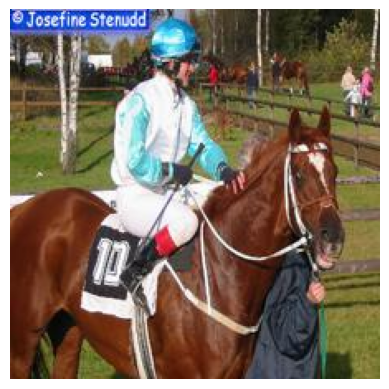

In [ ]:

im = Image.open(img)
im2 = np.array(im)
im2 = im2.astype(np.float64)
im_orig = im2 #  (224,224,3) 而且這裡的是小數化的整數表示，沒有經過data_mean跟data_sta前處理的 #Moreover, what is represented here is a decimalized integer representation, which has not been pre-processed by data_mean and data_sta.
print('im2.shape: ',im2.shape)
im_tensor = PreprocessImages([im_orig])
# Show the image
im_orig_int = np.int_(im_orig) #要從float轉成int才有辦法用ShowImage印出來 #You need to convert from float to int before you can print it out using ShowImage.
ShowImage(im_orig_int)
print('im_orig:',im_orig.shape, type(im_orig)) # im_orig:  (299, 299, 3) <class 'numpy.ndarray'>
print('im_tensor',im_tensor.shape,type(im_tensor))
print('im_tensor range',im_tensor.min(),im_tensor.max())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
im_tensor = im_tensor.to(device)


In [ ]:
predictions = model(im_tensor)
predictions = predictions.cpu().detach().numpy()
prediction_class = np.argmax(predictions[0])

print("Prediction class: " + str(prediction_class))  # Should be a doberman, class idx = 236
origin_prediction_class = prediction_class
im = im_orig.astype(np.float32)
print('im: ',im.shape, type(im)) # im:  (299, 299, 3) <class 'numpy.ndarray'>
print('ori_image')
value_sort = np.sort(predictions[0])[::-1]
print(value_sort[:2][0], value_sort[:2][1])
score_diff = value_sort[:2][0] - value_sort[:2][1]
print('dump score diff:',score_diff)

Prediction class: 339
im:  (224, 224, 3) <class 'numpy.ndarray'>
ori_image
25.732843 18.80044
dump score diff: 6.9324036


In [ ]:
value_sort = np.sort(predictions[0])[::-1]
index_sort = np.argsort(predictions[0])[::-1]
for i in range(5):
    print('label: ',index_sort[:5][i], ' score: ',value_sort[:5][i])

label:  339  score:  25.732843
label:  603  score:  18.80044
label:  912  score:  17.011047
label:  427  score:  15.770437
label:  756  score:  15.04903


### 攻擊開始
### Attack begins

Experimenting 2 cell

In [ ]:
adv_expl, adv_acc, class_idx = get_expl(model, x_adv, method, desired_index=org_idx)
#print('adv_expl',adv_expl)
#print('adv_acc',adv_acc)
#print('class_index',class_idx)

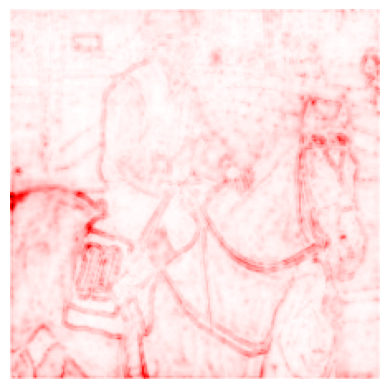

In [ ]:
show_expl_title(adv_expl, cm = 'seismic')
# autumn, bone, cool, copper, flag, gray, hot, hsv, inferno,
# jet, magma, pink, plasma, prism, spring, summer, viridis, winter,
#im_adv = show_expl_title_return_im(adv_expl, cm='seismic')


In [ ]:
#import os
#os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"


In [ ]:
!nvidia-smi


Tue Apr 15 15:52:18 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   57C    P0             30W /   70W |    4138MiB /  15360MiB |     45%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Iteration 1: Total Loss: 1128.57275390625, Gini Loss: 1.1285698775509445e-07, Output Loss: 2.934248186647892e-07
Iteration 49: Total Loss: 1118.717529296875, Gini Loss: 1.1185654358314423e-07, Output Loss: 1.5205285308184102e-05
Iteration 99: Total Loss: 1107.85400390625, Gini Loss: 1.1076082273575594e-07, Output Loss: 2.4572640541009605e-05
Iteration 149: Total Loss: 1100.9486083984375, Gini Loss: 1.1006641642552495e-07, Output Loss: 2.8443500923458487e-05


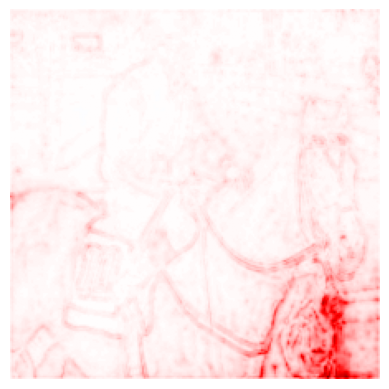

In [ ]:
total_loss_list = []
epoch_exp = []
L1_score = []
L2_score = []
L3_score = []
L4_score = []
L5_score = []

early_stop_epoch = 0
mode_2_loss = False
EARLY_STOP = True #False
for i in range(num_iter):
    if beta_growth:
        model.change_beta(get_beta(i, num_iter))

    optimizer.zero_grad()

    # calculate loss
    adv_expl, adv_acc, class_idx = get_expl(model, x_adv, method, desired_index=org_idx)

    loss_center = F.mse_loss(adv_expl, target_mtx_torch)
    loss_output = F.mse_loss(adv_acc[0][prediction_class], org_acc[0][prediction_class].detach())
    #loss_output = F.mse_loss(adv_acc, org_acc.detach())
    if mode_2_loss:
        total_loss = prefactors[0]*loss_output + prefactors[1]*loss_center
    else:
        total_loss = prefactors[0]*loss_output + prefactors[1]*loss_center

    total_loss_list.append(total_loss.item())
    x_tmp = x_adv
    # update adversarial example
    total_loss.backward()
    optimizer.step()
    predictions = model(x_adv)
    predictions = predictions.cpu().detach().numpy()
    if (value_sort[:2][0] - value_sort[:2][1]) < 1 :
        mode_2_loss = True
    #print(i,predictions[0][prediction_class], value_sort[:2][0], value_sort[:2][1])
    L1_score.append(predictions[0][index_sort[:5][0]])
    L2_score.append(predictions[0][index_sort[:5][1]])
    L3_score.append(predictions[0][index_sort[:5][2]])
    L4_score.append(predictions[0][index_sort[:5][3]])
    L5_score.append(predictions[0][index_sort[:5][4]])
    prediction_class_tmp = np.argmax(predictions[0])
    if(prediction_class != prediction_class_tmp):
        print(i,'early done')
        early_stop_epoch = i
        if EARLY_STOP == True:
            x_adv = x_tmp
            break

    x_adv.data = clamp(x_adv.data, data_mean, data_std)
    if i == 1:
        print("Iteration {}: Total Loss: {}, Gini Loss: {}, Output Loss: {}".format(i, total_loss.item(), loss_center.item(), loss_output.item()))
    #print("Iteration {}: Total Loss: {}, Expl Loss: {}, Output Loss: {}".format(i, total_loss.item(), loss_expl.item(), loss_output.item()))

    if (i+1)%50 == 0:
        print("Iteration {}: Total Loss: {}, Gini Loss: {}, Output Loss: {}".format(i, total_loss.item(), loss_center.item(), loss_output.item()))
        show_expl_title(adv_expl, cm = 'seismic')
        im_adv = show_expl_title_return_im(adv_expl, cm='seismic')
        epoch_exp.append(adv_expl)




# Computing Metrics

In [ ]:
# import numpy as np
# from skimage.metrics import mean_squared_error, structural_similarity
# from scipy.stats import pearsonr

# # Assuming x and x_adv are PyTorch tensors
# img1 = x.detach().cpu().numpy()
# img2 = x_adv.detach().cpu().numpy()

# # If they have shape (1, H, W) or (C, H, W), remove extra dims or convert to grayscale as needed
# if img1.ndim == 3 and img1.shape[0] == 1:
#     img1 = img1.squeeze(0)
#     img2 = img2.squeeze(0)

# # Flatten for PCC
# img1_flat = img1.flatten()
# img2_flat = img2.flatten()

# # Compute MSE
# mse_value = mean_squared_error(img1, img2)

# # Compute SSIM (if images are grayscale and 2D)
# #ssim_value, _ = structural_similarity(img1, img2, full=True)

# # Compute PCC
# pcc_value, _ = pearsonr(img1_flat, img2_flat)

# # Print results
# print(f'MSE: {mse_value:.4f}')
# #print(f'SSIM: {ssim_value:.4f}')
# print(f'PCC: {pcc_value:.4f}')


In [ ]:
# print(x)



```
# This is formatted as code
```

### 添加雜訊後
### After adding noise prediction score top 5

In [ ]:
# value_sort = np.sort(predictions[0])[::-1]
# index_sort = np.argsort(predictions[0])[::-1]
# for i in range(5):
#     print('label: ',index_sort[:5][i], ' score: ',value_sort[:5][i])

### 原始解釋圖
### original explanation diagram

In [ ]:
# # 目前解釋圖只有辦法存原論文的OAO #Currently, the only way to save explanation figures is in the OAO of the original paper.
# # 原始解釋圖
# show_expl_title(org_expl, cm= 'seismic')
# im_ori = show_expl_title_return_im(org_expl, cm='seismic')
# print('ori_exp')

### 擾動解釋圖
### Disturbance explanation diagram

In [ ]:
# # 擾動解釋圖 #Disturbance explanation diagram
# show_expl_title(adv_expl, cm = 'seismic')
# # autumn, bone, cool, copper, flag, gray, hot, hsv, inferno,
# # jet, magma, pink, plasma, prism, spring, summer, viridis, winter,
# im_adv = show_expl_title_return_im(adv_expl, cm='seismic')

# print('adv_expl')

### Metric

Original Explanation and Adversarial Explanation Computing metrics

In [ ]:
adv_expl_np = adv_expl[0].cpu().detach().numpy()
org_expl_np = org_expl[0].cpu().detach().numpy()
# Assuming adv_expl_np and org_expl_np are numpy arrays with values between 0 and 1
ssim_value = structural_similarity(adv_expl_np, org_expl_np, multichannel=True, data_range=adv_expl_np.max() - adv_expl_np.min())
print('ssim')
print('ori and adv :', ssim_value)
#print('ori and mal :', structural_similarity(org_expl_np, target_mtx, multichannel=True, data_range=adv_expl_np.max() - adv_expl_np.min()))
#print('adv and mal :', structural_similarity(adv_expl_np, target_mtx, multichannel=True, data_range=adv_expl_np.max() - adv_expl_np.min()))



ssim
ori and adv : 0.8013261609996318


In [ ]:
# print('mse')
print('ori and adv :', mean_squared_error(adv_expl_np, org_expl_np))

ori and adv : 8.601890745592865e-10


In [ ]:

# # print('ssim')
# # print('ori and adv :', structural_similarity(adv_expl_np, org_expl_np, channel_axis=-1))
# # print('ori and mal :', structural_similarity(org_expl_np, target_mtx, channel_axis=-1))
# # print('adv and mal :', structural_similarity(adv_expl_np, target_mtx, channel_axis=-1))

# # print('ori and adv :', structural_similarity(adv_expl_np, org_expl_np, multichannel=True))
# # print('ori and mal :', structural_similarity(org_expl_np, target_mtx, multichannel=True))
# # print('adv and mal :', structural_similarity(adv_expl_np, target_mtx, multichannel=True))

# print('mse')
# print('ori and adv :', mean_squared_error(adv_expl_np, org_expl_np))
# print('ori and mal :', mean_squared_error(org_expl_np, target_mtx))
# print('adv and mal :', mean_squared_error(adv_expl_np, target_mtx))

# print('psnr')

# # extra added Ensure all images have the same dtype
# org_expl_np = org_expl_np.astype(np.float64)
# adv_expl_np = adv_expl_np.astype(np.float64)
# target_mtx = target_mtx.astype(np.float64)

# print('ori and adv :', peak_signal_noise_ratio(adv_expl_np, org_expl_np))
# print('ori and mal :', peak_signal_noise_ratio(org_expl_np, target_mtx))
# print('adv and mal :', peak_signal_noise_ratio(adv_expl_np, target_mtx))

In [ ]:
# topk = 90
# im = Image.open(img)
# im2 = np.array(im)
# im2 = np.resize(im2,(224,224,3))
# adv_expl_np = adv_expl.detach().cpu().numpy()
# mask = adv_expl_np > np.percentile(adv_expl_np, topk) #取出指定容器內幾%的值(pr值)
# im2[~mask[0]] = 0
# ShowImage(im2, 'Top 10%')

# im = Image.open(red)
# im2 = np.array(im)
# im2 = np.resize(im2,(224,224,3))
# mask = adv_expl_np > np.percentile(adv_expl_np, topk) #取出指定容器內幾%的值(pr值) #Take out a few percent of the value (pr value) in the specified container
# im2[~mask[0]] = 0
# ShowImage(im2, 'Top 10%')
# print('top10_adv','top10_adv_red')

experiment on Gini Computation

In [ ]:
# def gini(array):
#     array = np.array(array, dtype=np.float64)
#     array = np.abs(array)
#     # Values cannot be 0:
#     array += 0.0000001
#     # Values must be sorted:
#     array = np.sort(array)
#     # Index per array element:
#     index = np.arange(1, array.shape[0] + 1)
#     # Number of array elements:
#     n = array.shape[0]
#     # Gini coefficient:
#     return ((np.sum((2 * index - n - 1) * array)) / (n * np.sum(array)))


In [ ]:
# gini(adv_expl_np)

In [ ]:
# gini(org_expl_np)

In [ ]:
# # computing GINI
# from skimage import color

# GINI_list = []
# ori_gini_list = []
# adv_gini_list = []
# adv_expl_np = adv_expl[0].cpu().detach().numpy()
# org_expl_np = org_expl[0].cpu().detach().numpy()
# # im_orig_path = 'output/'+'gradient_' + str(11) + '_ori_img.npy'
# # im_adv_path = 'output/'+'gradient_' + str(11) + '_adv_img.npy'
# # im_orig = np.load(im_orig_path)
# # im_adv = np.load(im_adv_path)

# img1 = org_expl_np
# img2 = adv_expl_np
# # img1_gray = color.rgb2gray(img1)
# # img2_gray = color.rgb2gray(img2)
# GINI_diff = np.abs(gini(img1.flatten()) - gini(img2.flatten()))
# GINI_list.append(GINI_diff)
# ori_gini_list.append(gini(img1.flatten()))
# adv_gini_list.append(gini(img2.flatten()))

In [ ]:
# print(GINI_diff)

In [ ]:
# print(GINI_list)
# print(ori_gini_list)
# print(adv_gini_list)

# Experimenting on new evaluation metrics

In [ ]:
# generated_map = adv_expl[0].cpu().detach().numpy()
# original_map = org_expl[0].cpu().detach().numpy()

New Evaluation Metrics

In [ ]:
# import numpy as np

# def get_top_25_percent_positions(saliency_map, percent=0.05):
#     """
#     Find the positions of the top percent highest pixel values in a saliency map.

#     Parameters:
#     saliency_map (np.ndarray): Saliency map.
#     percent (float): Percentage of top pixels to consider.

#     Returns:
#     positions (set): Set of positions of the top percent highest pixels.
#     """
#     num_pixels = saliency_map.size
#     num_top_pixels = int(num_pixels * percent)

#     # Flatten the saliency map and get the indices of the top percent pixels
#     flattened_map = saliency_map.flatten()
#     top_indices = np.argpartition(flattened_map, -num_top_pixels)[-num_top_pixels:]

#     # Convert flat indices to 2D positions
#     #positions = set(np.unravel_index(top_indices, saliency_map.shape))
#     positions = set(zip(*np.unravel_index(top_indices, saliency_map.shape)))


#     return positions

# def compare_top_pixel_positions(orig_positions, adv_positions):
#     """
#     Compare the positions of the top pixels between original and adversarial maps.

#     Parameters:
#     orig_positions (set): Set of positions in the original saliency map.
#     adv_positions (set): Set of positions in the adversarial saliency map.

#     Returns:
#     num_matching (int): Number of matching positions.
#     num_not_matching (int): Number of non-matching positions.
#     """
#     matching_positions = orig_positions & adv_positions
#     num_matching = len(matching_positions)
#     num_not_matching = len(orig_positions) - num_matching

#     return num_matching, num_not_matching

# # Example usage:
# original_saliency_map = original_map # Replace with actual saliency map
# adversarial_saliency_map = generated_map  # Replace with actual adversarial saliency map

# # Get the top 25% highest pixel positions for both maps
# orig_top_positions = get_top_25_percent_positions(original_saliency_map)
# adv_top_positions = get_top_25_percent_positions(adversarial_saliency_map)

# # Compare the positions
# num_matching, num_not_matching = compare_top_pixel_positions(orig_top_positions, adv_top_positions)

# print(f"Number of matching positions: {num_matching}")
# print(f"Number of non-matching positions: {num_not_matching}")


Cosine similarity measures the cosine of the angle between two non-zero vectors, reflecting how similar the two vectors are.

In [ ]:
# from sklearn.metrics.pairwise import cosine_similarity

# def compute_cosine_similarity(original_map, generated_map):
#     original_flat = original_map.flatten().reshape(1, -1)
#     generated_flat = generated_map.flatten().reshape(1, -1)

#     cosine_sim = cosine_similarity(original_flat, generated_flat)
#     return cosine_sim[0][0]


In [ ]:
# cosine_sim = compute_cosine_similarity(original_map, generated_map)
# print("Cosine Similarity:", cosine_sim)

The Pearson or Spearman correlation coefficient measures the linear relationship between the pixel values in the original and generated saliency maps.

In [ ]:
# from scipy.stats import pearsonr
# #Pearson Correlation: Measures the linear correlation between two datasets.

# def compute_pearson_correlation(original_map, generated_map):
#     original_flat = original_map.flatten()
#     generated_flat = generated_map.flatten()
#     correlation, _ = pearsonr(original_flat, generated_flat)
#     return correlation
# from scipy.stats import spearmanr
# #Spearman Correlation: Measures the rank correlation (non-linear).
# def compute_spearman_correlation(original_map, generated_map):
#     original_flat = original_map.flatten()
#     generated_flat = generated_map.flatten()
#     correlation, _ = spearmanr(original_flat, generated_flat)
#     return correlation


In [ ]:
# pearson_corr = compute_pearson_correlation(original_map, generated_map)
# spearman_corr = compute_spearman_correlation(original_map, generated_map)
# print("Pearson Correlation:", pearson_corr)
# print("Spearman Correlation:", spearman_corr)

KL Divergence

Kullback-Leibler (KL) divergence measures how one probability distribution diverges from a second, expected probability distribution.

In [ ]:
# import scipy

# def compute_kl_divergence(original_map, generated_map):
#     original_flat = original_map.flatten() + 1e-12  # Adding small constant to avoid log(0)
#     generated_flat = generated_map.flatten() + 1e-12

#     kl_div = scipy.stats.entropy(original_flat, generated_flat)
#     return kl_div
# kl_div = compute_kl_divergence(original_map, generated_map)
# print("KL Divergence:", kl_div)

Show kl-divergence visualization as you get another attack to show the difference or your own defended saliency map which is nearer to original saliency map

Through Histogram Representation way

In [ ]:
# Comparison Metrics:
# Correlation: Measures how closely the two histograms are correlated.
# Chi-Square: Measures the difference between two histograms.
# Intersection: Measures the overlap between the two histograms.
# Bhattacharyya Distance: Measures the similarity between the two histograms.

Comparing histograms of the original and generated saliency maps can indicate how similar their pixel distributions are.

KDE stands for Kernel Density Estimate, which is a non-parametric way to estimate the probability density function of a random variable.

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Assuming 'generated_map' and 'original_map' are your saliency maps
# # generated_map = adv_expl[0].cpu().detach().numpy()
# # original_map = org_expl[0].cpu().detach().numpy()

# # Flatten the maps to 1D arrays for plotting
# generated_map_flat = generated_map.flatten()
# original_map_flat = original_map.flatten()

# # Plot KDEs to compare pixel intensities
# plt.figure(figsize=(10, 6))

# sns.kdeplot(generated_map_flat, color='red', label='Generated Saliency Map', fill=False)
# sns.kdeplot(original_map_flat, color='green', label='Original Saliency Map', fill=False)

# plt.title('KDE Comparison of Pixel Intensities: Generated vs. Original Saliency Maps')
# plt.xlabel('Pixel Intensity')
# plt.ylabel('Density')
# plt.legend()

# # Show the plot
# plt.show()


In [ ]:
# import cv2
# # Compare histograms using various methods
# correlation = cv2.compareHist(original_map_flat, generated_map_flat, cv2.HISTCMP_CORREL)
# chi_square = cv2.compareHist(original_map_flat, generated_map_flat, cv2.HISTCMP_CHISQR)
# intersection = cv2.compareHist(original_map_flat, generated_map_flat, cv2.HISTCMP_INTERSECT)
# bhattacharyya = cv2.compareHist(original_map_flat, generated_map_flat, cv2.HISTCMP_BHATTACHARYYA)
# # Output the comparison results
# print(f"Correlation: {correlation}")
# print(f"Chi-Square: {chi_square}")
# print(f"Intersection: {intersection}")
# print(f"Bhattacharyya Distance: {bhattacharyya}")

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# # Assuming 'generated_map' and 'original_map' are your saliency maps
# # generated_map = adv_expl[0].cpu().detach().numpy()
# # original_map = org_expl[0].cpu().detach().numpy()

# # Flatten the maps to 1D arrays for plotting
# generated_map_flat = generated_map.flatten()
# original_map_flat = original_map.flatten()

# # Plot the histograms in the same graph to compare
# plt.figure(figsize=(10, 6))

# plt.hist(generated_map_flat, bins=10, color='red', alpha=0.5, label='Generated Saliency Map', density=True)
# plt.hist(original_map_flat, bins=10, color='green', alpha=0.5, label='Original Saliency Map', density=True)

# plt.title('Comparison of Pixel Intensities: Generated vs. Original Saliency Maps')
# plt.xlabel('Pixel Intensity')
# plt.ylabel('Density')
# plt.legend()

# # Show the plot
# plt.show()


CDFs are particularly useful for comparing the overall shape and spread of two distributions. If the CDFs are similar, the distributions are similar; differences in the CDFs highlight differences in the distributions.

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# # Assuming 'generated_map' and 'original_map' are your saliency maps
# # generated_map = adv_expl[0].cpu().detach().numpy()
# # original_map = org_expl[0].cpu().detach().numpy()

# # Flatten the maps to 1D arrays
# generated_map_flat = generated_map.flatten()
# original_map_flat = original_map.flatten()

# # Sort the flattened arrays for cumulative distribution
# sorted_generated = np.sort(generated_map_flat)
# sorted_original = np.sort(original_map_flat)

# # Compute the CDFs
# cdf_generated = np.arange(1, len(sorted_generated) + 1) / len(sorted_generated)
# cdf_original = np.arange(1, len(sorted_original) + 1) / len(sorted_original)

# # Plot CDFs
# plt.figure(figsize=(10, 6))

# plt.plot(sorted_generated, cdf_generated, label='Generated Saliency Map', color='blue')
# plt.plot(sorted_original, cdf_original, label='Original Saliency Map', color='green')

# plt.title('CDF Comparison of Pixel Intensities: Generated vs. Original Saliency Maps')
# plt.xlabel('Pixel Intensity')
# plt.ylabel('Cumulative Probability')
# plt.legend()

# # Show the plot
# plt.show()


# New experimentation to generate original saliency map by utilizing malicious saliency map

In [ ]:
# #First Attempt
# import numpy as np
# import torch

# def defend_adversarial_saliency(x, y, adv_saliency_map, image_size, radius=None):
#     L = image_size
#     e = adv_saliency_map.flatten()
#     e_sorted = np.sort(e)[::-1]
#     M = np.zeros((L, L))

#     # First step: Calculate distance from (x, y) and set in M
#     for i in range(L):
#         for j in range(L):
#             M[i, j] = abs(i - x) + abs(j - y)

#     # Second step: Adjust M based on the radius
#     for i in range(L):
#         for j in range(L):
#             if radius is not None:
#                 if M[i, j] > radius:
#                     M[i, j] = 0
#                 else:
#                     M[i, j] = e_sorted[np.sum(M < M[i, j])]
#             else:
#                 M[i, j] = e_sorted[np.sum(M < M[i, j])]

#     return M


In [ ]:
# # Example usage
# image_size = 224
# x, y = 112, 112  # Example coordinates, center of the image
# adv_saliency_map = adv_expl_np
# radius = 35  # Example radius

# original_saliency_map = defend_adversarial_saliency(x, y, adv_saliency_map, image_size, radius)
# print(original_saliency_map)

In [ ]:
# # second Attempt
# import numpy as np
# import matplotlib.pyplot as plt
# import torch

# def defend_adversarial_saliency(x, y, adv_saliency_map, image_size, radius=None):
#     L = image_size
#     e = adv_saliency_map.flatten()
#     e_sorted = np.sort(e)[::-1]
#     M = np.zeros((L, L))

#     # First step: Calculate distance from (x, y) and set in M
#     for i in range(L):
#         for j in range(L):
#             M[i, j] = abs(i - x) + abs(j - y)

#     # Second step: Adjust M based on the radius
#     for i in range(L):
#         for j in range(L):
#             if radius is not None:
#                 if M[i, j] > radius:
#                     M[i, j] = 0
#                 else:
#                     M[i, j] = e_sorted[np.sum(M < M[i, j])]
#             else:
#                 M[i, j] = e_sorted[np.sum(M < M[i, j])]

#     return M



In [ ]:
# # Example usage
# image_size = 224
# x, y = 112, 112  # Example coordinates, center of the image
# adv_saliency_map = adv_expl_np
# radius = 35  # Example radius

# original_saliency_map = defend_adversarial_saliency(x, y, adv_saliency_map, image_size, radius)

# # Display the original saliency map
# plt.imshow(original_saliency_map, cmap='seismic')
# plt.title('Original Saliency Map')
# plt.colorbar()
# plt.show()


New Idea attack recover

In [ ]:
# total_loss_list = []
# epoch_exp = []
# L1_score = []
# L2_score = []
# L3_score = []
# L4_score = []
# L5_score = []

# early_stop_epoch = 0
# mode_2_loss = False
# EARLY_STOP = True#False
# for i in range(snumiter):
#     if beta_growth:
#         model.change_beta(get_beta(i, snumiter))

#     optimizer.zero_grad()

#     # calculate loss
#     adv_expl, adv_acc, class_idx = get_expl(model, x_adv, method, desired_index=org_idx)
#     loss_center = F.mse_loss(adv_expl, target_mtx_torch)
#     #loss_output = F.mse_loss(adv_acc[0][prediction_class], org_acc[0][prediction_class].detach())
#     #loss_output = F.mse_loss(adv_acc, org_acc.detach())
#     if mode_2_loss:
#         total_loss = prefactors[1]*loss_center
#     else:
#         total_loss = prefactors[1]*loss_center

#     total_loss_list.append(total_loss.item())
#     x_tmp = x_adv
#     # update adversarial example
#     total_loss.backward()
#     optimizer.step()
#     predictions = model(x_adv)
#     predictions = predictions.cpu().detach().numpy()
#     if (value_sort[:2][0] - value_sort[:2][1]) < 1 :
#         mode_2_loss = True
#     #print(i,predictions[0][prediction_class], value_sort[:2][0], value_sort[:2][1])
#     L1_score.append(predictions[0][index_sort[:5][0]])
#     L2_score.append(predictions[0][index_sort[:5][1]])
#     L3_score.append(predictions[0][index_sort[:5][2]])
#     L4_score.append(predictions[0][index_sort[:5][3]])
#     L5_score.append(predictions[0][index_sort[:5][4]])
#     prediction_class_tmp = np.argmax(predictions[0])
#     if(prediction_class != prediction_class_tmp):
#         print(i,'early done')
#         early_stop_epoch = i
#         if EARLY_STOP == True:
#             x_adv = x_tmp
#             break

#     x_adv.data = clamp(x_adv.data, data_mean, data_std)
#     if i == 1:
#         print("Iteration {}: Total Loss: {}, Gini Loss: {}, Output Loss: {}".format(i, total_loss.item(), loss_center.item(), loss_output.item()))
#     #print("Iteration {}: Total Loss: {}, Expl Loss: {}, Output Loss: {}".format(i, total_loss.item(), loss_expl.item(), loss_output.item()))

#     if (i+1)%50 == 0:
#         print("Iteration {}: Total Loss: {}, Gini Loss: {}, Output Loss: {}".format(i, total_loss.item(), loss_center.item(), loss_output.item()))
#         epoch_exp.append(adv_expl)

